# **Project Name**
Vaccination Data Analysis and Visualization


##### **Project Type** - EDA / Data Analysis  
##### **Contribution** - Individual  
##### **Team Member 1** - [Arunav Kumar]

# **Project Summary -**


This project analyzes global vaccination coverage, disease incidence, reported cases, vaccine introduction, and vaccine schedule data to understand long-term immunization trends and their relationship with disease indicators. The project belongs to the Public Health and Epidemiology domain and combines Python-based data cleaning and exploratory data analysis (EDA), SQL-based storage and querying, and Power BI visualization. Five source datasets were processed: vaccination coverage, disease incidence rate, reported cases, vaccine introduction, and vaccine schedule data.

The data preparation stage focused on duplicate checks, missing-value checks, removal of footer or artifact rows, country-level and group-level separation, and consistency checks for country codes. Clean country-level datasets were exported to CSV and loaded into a SQLite database named `vaccination.db`. The database contains eight tables covering country-level and group-level coverage, incidence, and reported cases, along with vaccine introduction and vaccine schedule information. SQL queries were used to validate table structures and examine analytical questions such as high DTP3 coverage in 2023, high MCV1 coverage with notable measles incidence, disease and antigen diagnostics, denominator checks, and vaccine introduction patterns.

EDA shows a strong long-term increase in global WUENIC vaccination coverage. The global average rose from about 53.3% in 1980 to 86.9% in 2019. It then declined to about 82.9% in 2021 and reached about 84.1% in 2023, indicating recovery after the pandemic-period decline but not a return to the 2019 level in the analyzed series. Regional trends also differ. In the notebook analysis, EURO remained above 90% around 2019–2023, while AFRO remained lower than the other WHO regions in those years. These differences highlight the importance of regional monitoring and targeted resource planning.

The project also examines the relationship between MCV1 vaccination coverage and measles incidence. The merged MCV1/measles dataset contains 8,051 country-year observations and shows a Pearson correlation of approximately -0.214. A simple correlation should not be interpreted as a causal estimate; however, the coverage-bracket analysis shows a descriptive pattern in this dataset: median measles incidence decreases from 400.6 for observations below 50% MCV1 coverage to 1.0 for observations in the 95–100% bracket. The incidence data uses different denominators across diseases, so comparisons between different diseases require caution.

The final Power BI report presents interactive views of vaccination coverage trends, country-level coverage, WHO-region schedule complexity, a 2023 coverage map, disease incidence trends, vaccination coverage versus disease incidence, vaccine introduction trends, and KPI indicators. Together, the Python, SQL, and Power BI components provide a reproducible workflow for cleaning public-health data, validating it in a relational database, exploring patterns, and communicating findings for vaccination program monitoring. The project also documents limitations, including the absence of demographic variables such as gender, education, and urban/rural status in the provided tables. Therefore, those requested dimensions cannot be directly evaluated from this dataset.

# **GitHub Link -**


GitHub repository: **Not provided / to be added before submission.**

# **Problem Statement**


Analyze global vaccination data to understand trends in vaccination coverage, disease incidence, and reported cases, while examining vaccine introduction and schedule patterns. The data should be cleaned, stored in a structured SQL database, analyzed with EDA, and presented through interactive Power BI dashboards to support evidence-based monitoring of vaccination programs and disease-control indicators.


#### **Define Your Business Objective?**


The objective is to identify vaccination coverage trends, regional disparities, disease-incidence patterns, and vaccine introduction/schedule differences. The analysis should help public-health stakeholders identify areas requiring closer monitoring, compare trends across regions and years, and use consistent data for resource planning and vaccination-program evaluation. Findings are descriptive and should not be interpreted as causal estimates without additional epidemiological controls.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


### Dataset Loading

In [2]:
from pathlib import Path

def pick(*names):
    for n in names:
        p=Path(n)
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find any of: {names}")

coverage = pd.read_csv(pick("coverage_countries.csv", "coverage_countries(1).csv"))
incidence = pd.read_csv(pick("incidence_countries.csv", "incidence_countries(1).csv"))
cases = pd.read_csv(pick("cases_countries.csv", "cases_countries(1).csv"))
intro = pd.read_csv(pick("vaccine_introduction.csv", "vaccine_introduction(1).csv"))
schedule = pd.read_csv(pick("vaccine_schedule.csv", "vaccine_schedule(1).csv"))

print("Coverage:", coverage.shape)
print("Incidence:", incidence.shape)
print("Cases:", cases.shape)
print("Introduction:", intro.shape)
print("Schedule:", schedule.shape)


Coverage: (381041, 11)
Incidence: (82054, 8)
Cases: (82054, 7)
Introduction: (138320, 6)
Schedule: (8052, 12)


### Dataset First View

In [3]:
display(coverage.head())
display(incidence.head())
display(cases.head())
display(intro.head())
display(schedule.head())


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52
3,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,NaN,NaN,90.52
4,COUNTRIES,ABW,Aruba,2023.0,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219.0,1008.0,82.69


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,"per 1,000,000 total population",NaN
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,"per 1,000,000 total population",0.0


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,NaN
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,0.0


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes
3,AFG,Afghanistan,EMRO,2023.0,HepB birth dose,Yes
4,AFG,Afghanistan,EMRO,2023.0,Hib (Haemophilus influenzae type B) vaccine,Yes


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN
3,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,4.0,B_2YL_W,General/routine,NATIONAL,M15,NaN
4,ABW,Aruba,AMRO,2023.0,DTAPIPV,DTaP-IPV (acellular) vaccine,5.0,B_CHILD_W,General/routine,NATIONAL,Y4,NaN


### Dataset Rows & Columns count

In [4]:
for name, df in {"Coverage":coverage,"Incidence":incidence,"Cases":cases,"Introduction":intro,"Schedule":schedule}.items():
    print(f"{name}: rows={len(df):,}, columns={df.shape[1]}")


Coverage: rows=381,041, columns=11
Incidence: rows=82,054, columns=8
Cases: rows=82,054, columns=7
Introduction: rows=138,320, columns=6
Schedule: rows=8,052, columns=12


### Dataset Information

In [5]:
for name, df in {"Coverage":coverage,"Incidence":incidence,"Cases":cases,"Introduction":intro,"Schedule":schedule}.items():
    print(f"\n--- {name} ---")
    print(df.info())



--- Coverage ---
<class 'pandas.DataFrame'>
RangeIndex: 381041 entries, 0 to 381040
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          381041 non-null  str    
 1   CODE                           381041 non-null  str    
 2   NAME                           381041 non-null  str    
 3   YEAR                           381041 non-null  float64
 4   ANTIGEN                        381041 non-null  str    
 5   ANTIGEN_DESCRIPTION            381041 non-null  str    
 6   COVERAGE_CATEGORY              381041 non-null  str    
 7   COVERAGE_CATEGORY_DESCRIPTION  381041 non-null  str    
 8   TARGET_NUMBER                  60213 non-null   float64
 9   DOSES                          60560 non-null   float64
 10  COVERAGE                       211710 non-null  float64
dtypes: float64(4), str(7)
memory usage: 65.5 MB
None

--- Incidence ---
<class 'pandas.D

#### Duplicate Values

In [6]:
for name, df in {"Coverage":coverage,"Incidence":incidence,"Cases":cases,"Introduction":intro,"Schedule":schedule}.items():
    print(f"{name}: duplicate rows = {df.duplicated().sum():,}")


Coverage: duplicate rows = 0
Incidence: duplicate rows = 0
Cases: duplicate rows = 0
Introduction: duplicate rows = 0
Schedule: duplicate rows = 0


#### Missing Values/Null Values

In [7]:
for name, df in {"Coverage":coverage,"Incidence":incidence,"Cases":cases,"Introduction":intro,"Schedule":schedule}.items():
    print(f"\n{name} missing values:")
    display(df.isna().sum().sort_values(ascending=False).head(15))



Coverage missing values:


TARGET_NUMBER                    320828
DOSES                            320481
COVERAGE                         169331
NAME                                  0
CODE                                  0
GROUP                                 0
YEAR                                  0
COVERAGE_CATEGORY                     0
ANTIGEN_DESCRIPTION                   0
ANTIGEN                               0
COVERAGE_CATEGORY_DESCRIPTION         0
dtype: int64


Incidence missing values:


INCIDENCE_RATE         23145
GROUP                      0
NAME                       0
CODE                       0
YEAR                       0
DISEASE                    0
DISEASE_DESCRIPTION        0
DENOMINATOR                0
dtype: int64


Cases missing values:


CASES                  19399
CODE                       0
GROUP                      0
NAME                       0
YEAR                       0
DISEASE                    0
DISEASE_DESCRIPTION        0
dtype: int64


Introduction missing values:


ISO_3_CODE     0
COUNTRYNAME    0
WHO_REGION     0
YEAR           0
DESCRIPTION    0
INTRO          0
dtype: int64


Schedule missing values:


TARGETPOP                4257
SOURCECOMMENT            2913
AGEADMINISTERED          1045
GEOAREA                    30
YEAR                        0
WHO_REGION                  0
COUNTRYNAME                 0
ISO_3_CODE                  0
SCHEDULEROUNDS              0
VACCINE_DESCRIPTION         0
VACCINECODE                 0
TARGETPOP_DESCRIPTION       0
dtype: int64

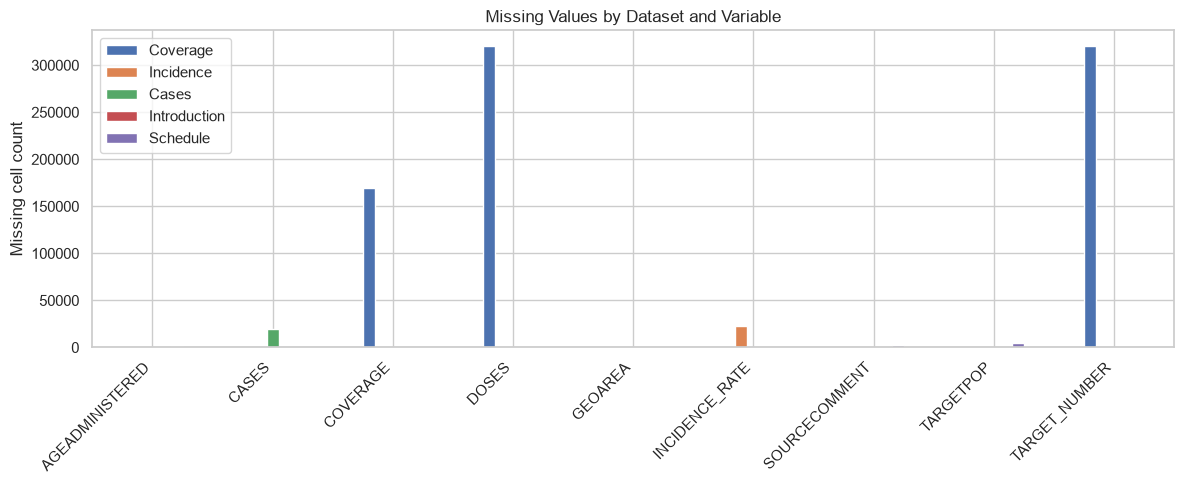

In [8]:
# Missing-value overview for the five cleaned datasets
missing = pd.DataFrame({
    "Coverage": coverage.isna().sum(),
    "Incidence": incidence.isna().sum(),
    "Cases": cases.isna().sum(),
    "Introduction": intro.isna().sum(),
    "Schedule": schedule.isna().sum()
}).fillna(0)
missing[missing.sum(axis=1)>0].plot(kind="bar", figsize=(12,5), title="Missing Values by Dataset and Variable")
plt.ylabel("Missing cell count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### What did you know about your dataset?

The project contains five country-level datasets covering vaccination coverage, disease incidence, reported cases, vaccine introduction, and vaccine schedules. The coverage data contains 381,041 country-level rows, incidence and reported-cases data each contain 82,054 rows, vaccine introduction contains 138,320 rows, and schedule data contains 8,052 rows after cleaning. The data spans multiple years and countries/areas. Coverage includes antigen and coverage-category information; incidence includes disease and denominator information; reported cases contains disease cases; introduction records WHO-region and introduction status; and schedule records vaccine rounds and target-population details.


## ***2. Understanding Your Variables***

In [9]:
for name, df in {"Coverage":coverage,"Incidence":incidence,"Cases":cases,"Introduction":intro,"Schedule":schedule}.items():
    print(name, "columns:", list(df.columns))


Coverage columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
Incidence columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']
Cases columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']
Introduction columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']
Schedule columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [10]:
display(coverage.describe(include="all").T)
display(incidence.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,381041,1,COUNTRIES,381041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,381041,214,ETH,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,381041,214,Ethiopia,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,381041.0,NaN,NaN,NaN,2009.30307,11.701035,1980.0,2002.0,2012.0,2019.0,2023.0
ANTIGEN,381041,68,DTPCV3,24651,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANTIGEN_DESCRIPTION,381041,68,"DTP-containing vaccine, 3rd dose",24651,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY,381041,5,ADMIN,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY_DESCRIPTION,381041,5,Administrative coverage,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGET_NUMBER,60213.0,NaN,NaN,NaN,356772500.983136,62039499436.74765,0.0,15563.0,115142.0,541026.0,11700000000000.0
DOSES,60560.0,NaN,NaN,NaN,550477.399843,2254009.475689,-222288203.0,9677.75,77971.0,402060.75,73953491.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,82054,1,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,82054,214,THA,414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,82054,214,Thailand,414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,82054.0,NaN,NaN,NaN,2004.090745,12.598984,1980.0,1994.0,2005.0,2015.0,2023.0
DISEASE,82054,13,MEASLES,8888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,82054,13,Measles,8888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DENOMINATOR,82054,4,"per 1,000,000 total population",59384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCIDENCE_RATE,58909.0,NaN,NaN,NaN,111.258473,1012.772661,0.0,0.0,0.0,4.0,69101.3


### Variables Description

The main analytical variables are YEAR, CODE/ISO_3_CODE, NAME/COUNTRYNAME, ANTIGEN, COVERAGE_CATEGORY, COVERAGE, DISEASE, DENOMINATOR, INCIDENCE_RATE, CASES, WHO_REGION, INTRO, and SCHEDULEROUNDS. Numeric measures are used for trend, comparison, correlation, and distribution analysis, while categorical variables provide country, disease, vaccine, and regional context.


### Check Unique Values for each variable.

In [11]:
for name, df in {"Coverage":coverage,"Incidence":incidence,"Cases":cases,"Introduction":intro,"Schedule":schedule}.items():
    print(f"\n{name} unique values (selected):")
    for col in df.columns[:6]:
        print(col, "->", df[col].nunique(dropna=True))



Coverage unique values (selected):
GROUP -> 1
CODE -> 214
NAME -> 214
YEAR -> 44
ANTIGEN -> 68
ANTIGEN_DESCRIPTION -> 68

Incidence unique values (selected):
GROUP -> 1
CODE -> 214
NAME -> 214
YEAR -> 44
DISEASE -> 13
DISEASE_DESCRIPTION -> 13

Cases unique values (selected):
GROUP -> 1
CODE -> 214
NAME -> 214
YEAR -> 44
DISEASE -> 13
DISEASE_DESCRIPTION -> 13

Introduction unique values (selected):
ISO_3_CODE -> 194
COUNTRYNAME -> 194
WHO_REGION -> 6
YEAR -> 84
DESCRIPTION -> 21
INTRO -> 9

Schedule unique values (selected):
ISO_3_CODE -> 213
COUNTRYNAME -> 213
WHO_REGION -> 6
YEAR -> 4
VACCINECODE -> 86
VACCINE_DESCRIPTION -> 86


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Data wrangling and analysis-readiness checks
# The source CSVs are already cleaned in the preceding data-cleaning workflow.
# Here we apply non-destructive validation/preparation steps for EDA.

analysis_frames = {
    "coverage": coverage,
    "incidence": incidence,
    "cases": cases,
    "intro": intro,
    "schedule": schedule
}

for name, df in analysis_frames.items():
    analysis_frames[name] = df.drop_duplicates().copy()

coverage = analysis_frames["coverage"]
incidence = analysis_frames["incidence"]
cases = analysis_frames["cases"]
intro = analysis_frames["intro"]
schedule = analysis_frames["schedule"]

for col in ["YEAR", "TARGET_NUMBER", "DOSES", "COVERAGE"]:
    if col in coverage.columns:
        coverage[col] = pd.to_numeric(coverage[col], errors="coerce")
for col in ["YEAR", "INCIDENCE_RATE"]:
    if col in incidence.columns:
        incidence[col] = pd.to_numeric(incidence[col], errors="coerce")
if "CASES" in cases.columns:
    cases["CASES"] = pd.to_numeric(cases["CASES"], errors="coerce")
if "YEAR" in cases.columns:
    cases["YEAR"] = pd.to_numeric(cases["YEAR"], errors="coerce")
for col in ["YEAR", "SCHEDULEROUNDS"]:
    if col in schedule.columns:
        schedule[col] = pd.to_numeric(schedule[col], errors="coerce")
if "YEAR" in intro.columns:
    intro["YEAR"] = pd.to_numeric(intro["YEAR"], errors="coerce")

print("Analysis-ready shapes:")
for name, df in {"Coverage":coverage,"Incidence":incidence,"Cases":cases,"Introduction":intro,"Schedule":schedule}.items():
    print(f"{name}: {df.shape}")

Analysis-ready shapes:
Coverage: (381041, 11)
Incidence: (82054, 8)
Cases: (82054, 7)
Introduction: (138320, 6)
Schedule: (8052, 12)


### What all manipulations have you done and insights you found?

The data-wrangling workflow removed footer/artifact rows, removed records without the required country/code identifiers for the country-level analysis, separated country-level records from group/region records where applicable, retained relevant variables, exported cleaned CSV files, and loaded the cleaned data into SQLite. Country-code checks were performed between coverage and vaccine-introduction data. The resulting country-level datasets are suitable for the project analyses, while incidence-rate comparisons across different diseases must account for the denominator used by each disease.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

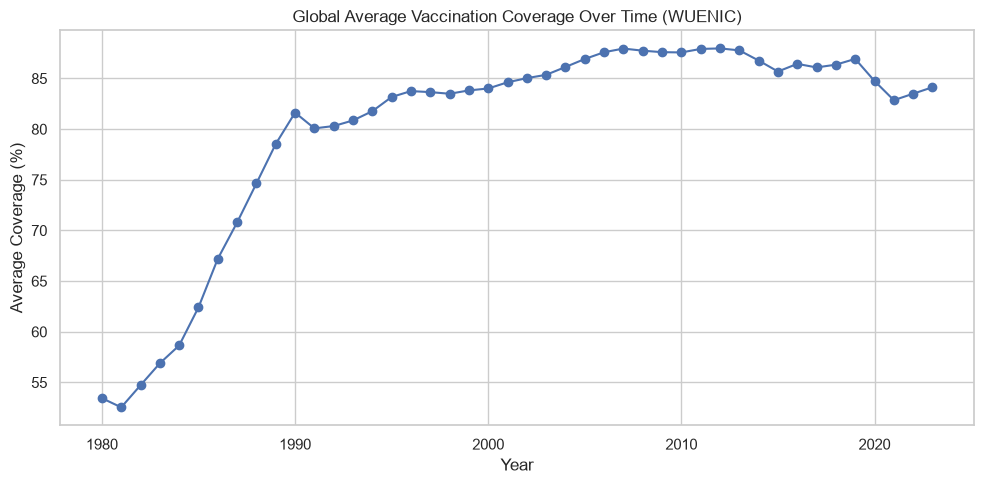

In [13]:
# Chart 1: Global WUENIC vaccination coverage trend
wu = coverage[(coverage["COVERAGE_CATEGORY"]=="WUENIC") & coverage["COVERAGE"].notna()].copy()
trend = wu.groupby("YEAR")["COVERAGE"].mean()
trend.plot(marker="o")
plt.title("Global Average Vaccination Coverage Over Time (WUENIC)")
plt.xlabel("Year"); plt.ylabel("Average Coverage (%)"); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A line chart is appropriate because vaccination coverage is a time-series measure and the goal is to observe long-term movement.


##### 2. What is/are the insight(s) found from the chart?

Global average WUENIC coverage increased substantially from about 53.3% in 1980 to about 86.9% in 2019. It declined to about 82.9% in 2021 and was about 84.1% in 2023.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The trend helps public-health stakeholders monitor long-term progress and identify periods of decline that may require closer investigation. The chart is descriptive and does not identify causes by itself.


#### Chart - 2

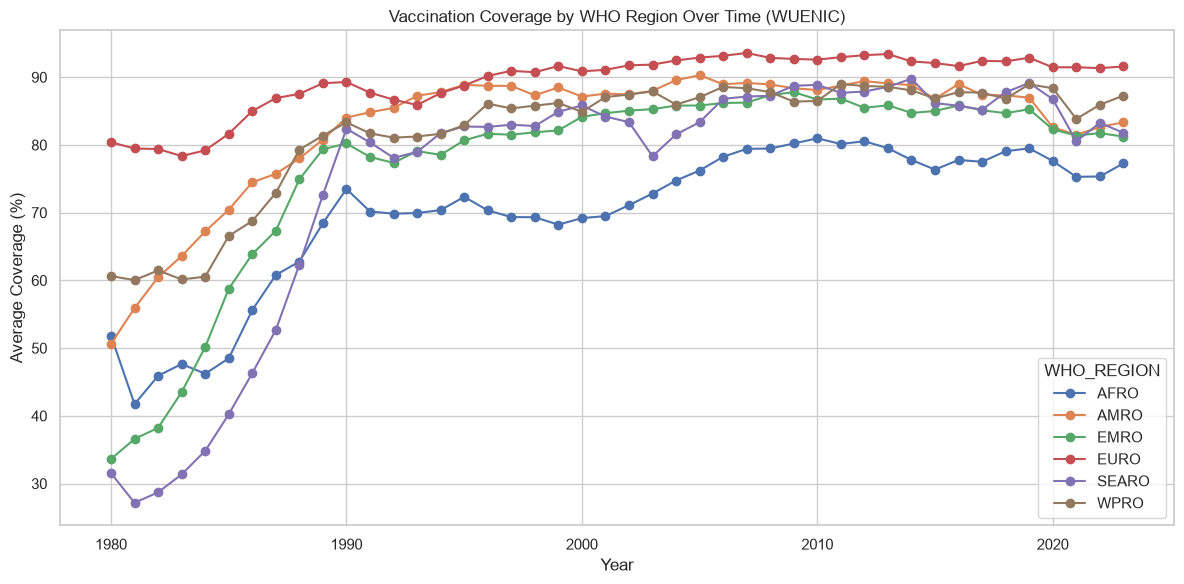

In [14]:
# Chart 2: WUENIC coverage by WHO region
# Join coverage country codes to WHO region from vaccine introduction.
regions = intro[["ISO_3_CODE","WHO_REGION"]].drop_duplicates().dropna()
wu_reg = wu.merge(regions, left_on="CODE", right_on="ISO_3_CODE", how="left")
regtrend = wu_reg.dropna(subset=["WHO_REGION"]).groupby(["YEAR","WHO_REGION"])["COVERAGE"].mean().unstack()
regtrend.plot(marker="o", figsize=(12,6))
plt.title("Vaccination Coverage by WHO Region Over Time (WUENIC)")
plt.xlabel("Year"); plt.ylabel("Average Coverage (%)"); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

Multiple regional lines allow the same coverage measure to be compared over time across WHO regions.


##### 2. What is/are the insight(s) found from the chart?

Regional trajectories differ. In the existing EDA, EURO is above 90% around 2019–2023, while AFRO remains lower than the other displayed regions.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Regional differences can support targeted monitoring and resource planning, especially where coverage remains persistently lower.


#### Chart - 3

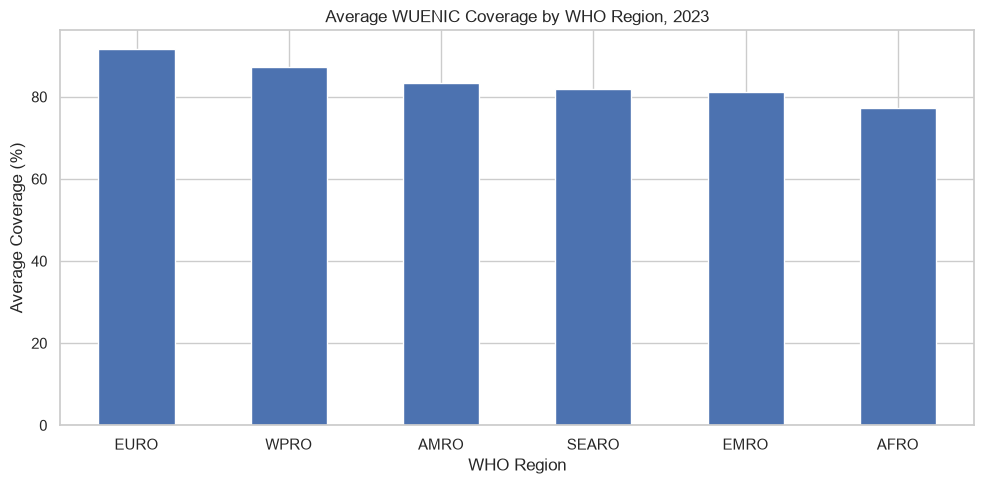

In [15]:
# Chart 3: 2023 average WUENIC coverage by WHO region
latest_reg = wu_reg[wu_reg["YEAR"]==2023].groupby("WHO_REGION")["COVERAGE"].mean().sort_values(ascending=False)
latest_reg.plot(kind="bar")
plt.title("Average WUENIC Coverage by WHO Region, 2023")
plt.xlabel("WHO Region"); plt.ylabel("Average Coverage (%)"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A bar chart makes the 2023 regional comparison easy to compare at a single point in time.


##### 2. What is/are the insight(s) found from the chart?

The 2023 regional averages show meaningful variation between WHO regions.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

A single-year regional view can help identify where further investigation or program support may be appropriate.


#### Chart - 4

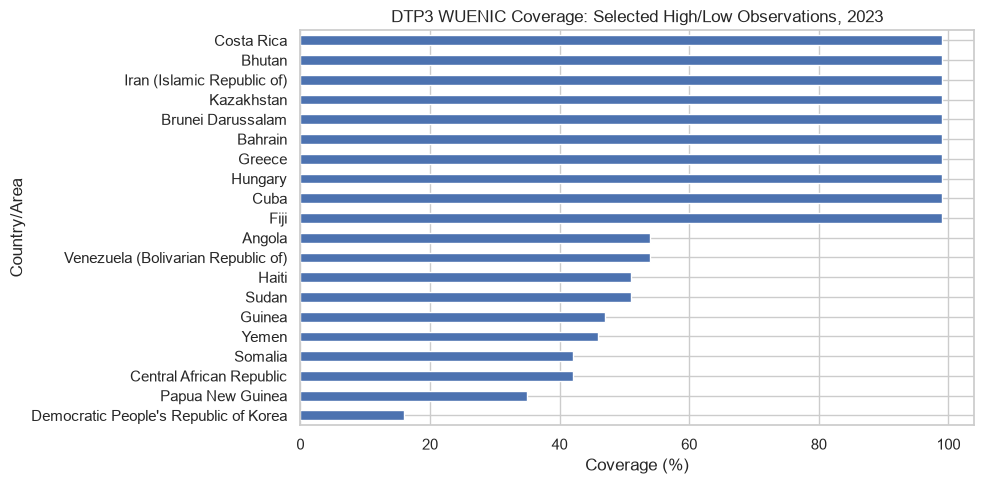

In [16]:
# Chart 4: Top and bottom DTP3 coverage observations in 2023
dtp3 = coverage[(coverage["ANTIGEN"]=="DTPCV3") & (coverage["COVERAGE_CATEGORY"]=="WUENIC") & (coverage["YEAR"]==2023)].dropna(subset=["COVERAGE"])
ranked = pd.concat([dtp3.nlargest(10,"COVERAGE"), dtp3.nsmallest(10,"COVERAGE")]).drop_duplicates(subset=["NAME"])
ranked = ranked.sort_values("COVERAGE")
ranked.plot(kind="barh", x="NAME", y="COVERAGE", legend=False)
plt.title("DTP3 WUENIC Coverage: Selected High/Low Observations, 2023")
plt.xlabel("Coverage (%)"); plt.ylabel("Country/Area"); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart is useful for comparing selected country observations with long country names.


##### 2. What is/are the insight(s) found from the chart?

The chart highlights variation in DTP3 WUENIC coverage among country observations in 2023.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Country-level differences can help prioritize deeper investigation of coverage gaps, while avoiding assumptions about the reasons for those gaps.


#### Chart - 5

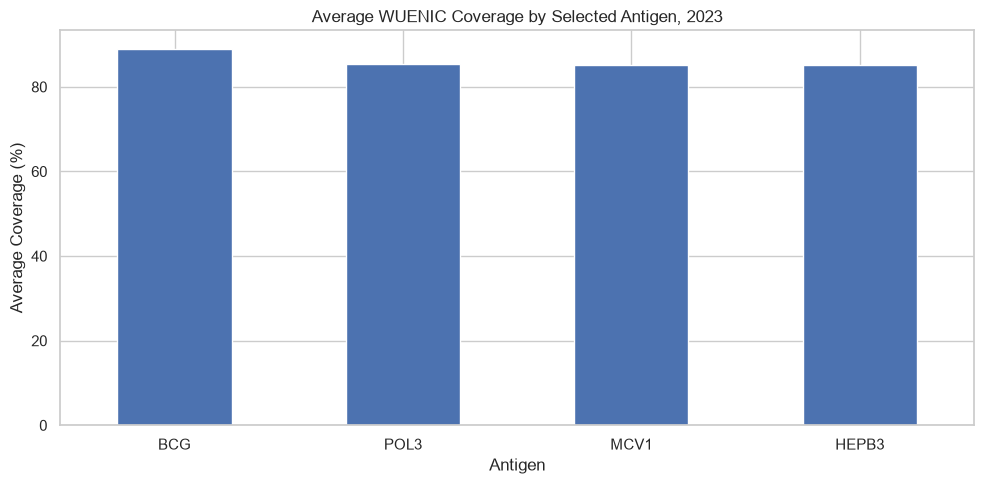

In [17]:
# Chart 5: Average 2023 WUENIC coverage for selected major antigens
sel = ["DTP3","MCV1","BCG","POL3","HEPB3"]
ant = coverage[(coverage["COVERAGE_CATEGORY"]=="WUENIC") & (coverage["YEAR"]==2023) & coverage["ANTIGEN"].isin(sel)]
ant_avg = ant.groupby("ANTIGEN")["COVERAGE"].mean().sort_values(ascending=False)
ant_avg.plot(kind="bar")
plt.title("Average WUENIC Coverage by Selected Antigen, 2023")
plt.xlabel("Antigen"); plt.ylabel("Average Coverage (%)"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A grouped antigen comparison shows whether commonly used vaccine indicators have similar or different average coverage levels.


##### 2. What is/are the insight(s) found from the chart?

Average 2023 WUENIC coverage varies across the selected antigens.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Comparing antigens can help identify indicators that merit closer monitoring in vaccination programs.


#### Chart - 6

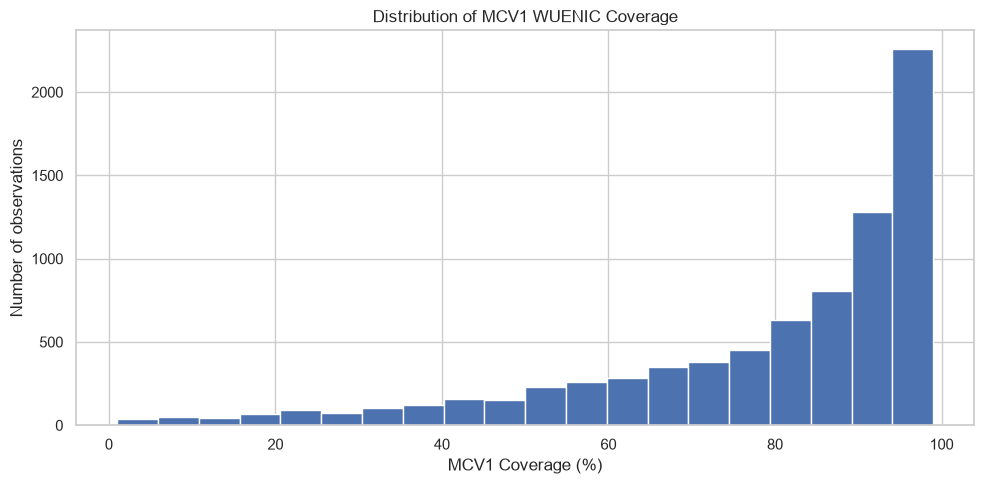

In [18]:
# Chart 6: Distribution of MCV1 WUENIC coverage
mcv1 = coverage[(coverage["ANTIGEN"]=="MCV1") & (coverage["COVERAGE_CATEGORY"]=="WUENIC")].dropna(subset=["COVERAGE"])
plt.hist(mcv1["COVERAGE"], bins=20)
plt.title("Distribution of MCV1 WUENIC Coverage")
plt.xlabel("MCV1 Coverage (%)"); plt.ylabel("Number of observations"); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A histogram shows the distribution of MCV1 coverage and whether observations cluster around high or low coverage ranges.


##### 2. What is/are the insight(s) found from the chart?

MCV1 coverage observations are concentrated toward higher coverage values, but there is still variation across country-year observations.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The distribution helps identify the coverage ranges where additional monitoring may be useful.


#### Chart - 7

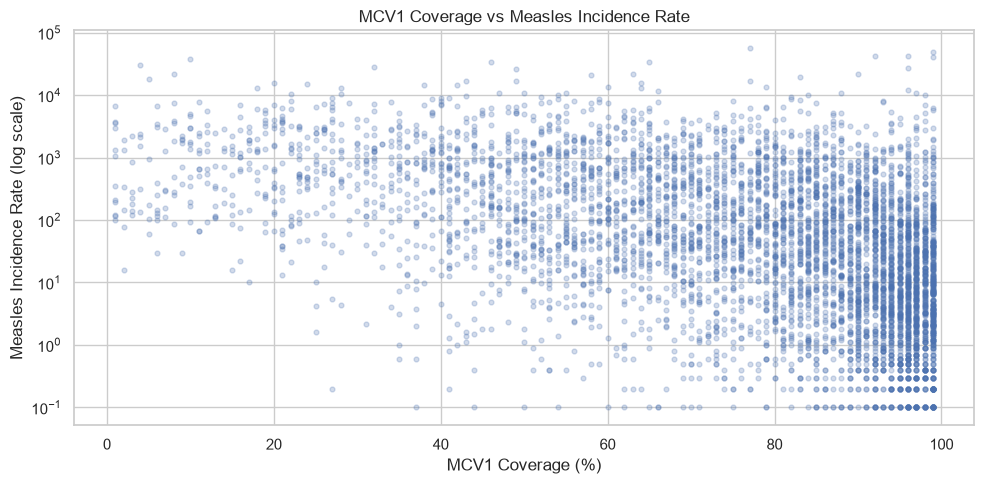

Pearson correlation: -0.21441869232058397


In [19]:
# Chart 7: MCV1 coverage versus measles incidence
meas = incidence[incidence["DISEASE"]=="MEASLES"][["CODE","YEAR","INCIDENCE_RATE"]].copy()
mc = mcv1[["CODE","NAME","YEAR","COVERAGE"]].copy()
merged = mc.merge(meas,on=["CODE","YEAR"],how="inner").dropna()
plt.scatter(merged["COVERAGE"], merged["INCIDENCE_RATE"], alpha=0.25, s=12)
plt.yscale("log")
plt.title("MCV1 Coverage vs Measles Incidence Rate")
plt.xlabel("MCV1 Coverage (%)"); plt.ylabel("Measles Incidence Rate (log scale)"); plt.tight_layout(); plt.show()
print("Pearson correlation:", merged["COVERAGE"].corr(merged["INCIDENCE_RATE"]))


##### 1. Why did you pick the specific chart?

A scatter plot is suitable for examining the relationship between two numeric variables: MCV1 coverage and measles incidence.


##### 2. What is/are the insight(s) found from the chart?

The merged analysis contains 8,051 observations and the Pearson correlation is approximately -0.214. The relationship is not adequately described by correlation alone.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The relationship can inform further epidemiological analysis, but the chart should not be interpreted as proof that vaccination coverage alone caused changes in incidence.


#### Chart - 8

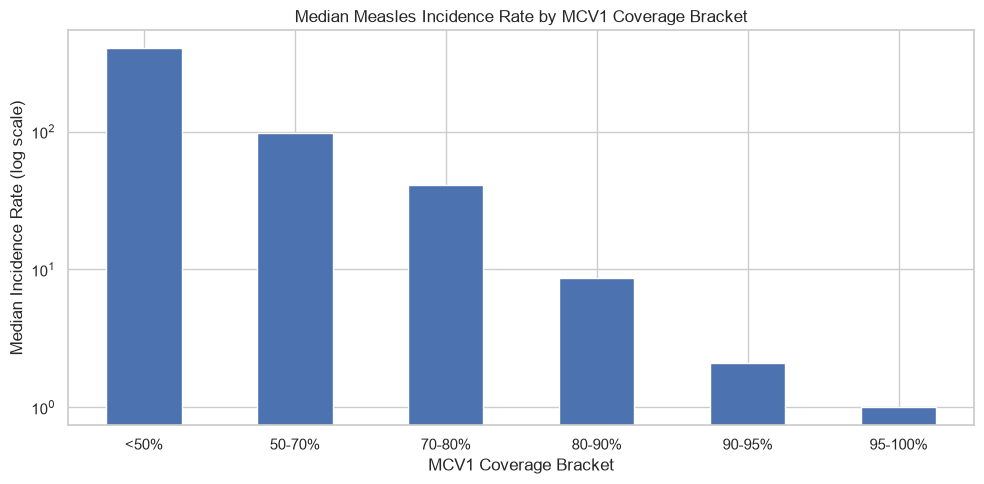

coverage_bin
<50%       400.6
50-70%      98.0
70-80%      40.9
80-90%       8.6
90-95%       2.1
95-100%      1.0
Name: INCIDENCE_RATE, dtype: float64


In [20]:
# Chart 8: Median measles incidence by MCV1 coverage bracket
merged["coverage_bin"] = pd.cut(merged["COVERAGE"], bins=[-np.inf,50,70,80,90,95,100], labels=["<50%","50-70%","70-80%","80-90%","90-95%","95-100%"], include_lowest=True)
bracket = merged.groupby("coverage_bin", observed=True)["INCIDENCE_RATE"].median()
bracket.plot(kind="bar")
plt.yscale("log")
plt.title("Median Measles Incidence Rate by MCV1 Coverage Bracket")
plt.xlabel("MCV1 Coverage Bracket"); plt.ylabel("Median Incidence Rate (log scale)"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print(bracket)


##### 1. Why did you pick the specific chart?

Coverage brackets make the non-linear pattern easier to inspect than a single correlation coefficient.


##### 2. What is/are the insight(s) found from the chart?

Median measles incidence decreases across the MCV1 coverage brackets in the analyzed data; the notebook analysis reports medians of 400.6 below 50% coverage and 1.0 in the 95–100% bracket.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The bracket analysis provides a useful descriptive signal for monitoring, but other factors and the time/denominator structure of incidence data must be considered before causal conclusions.


#### Chart - 9

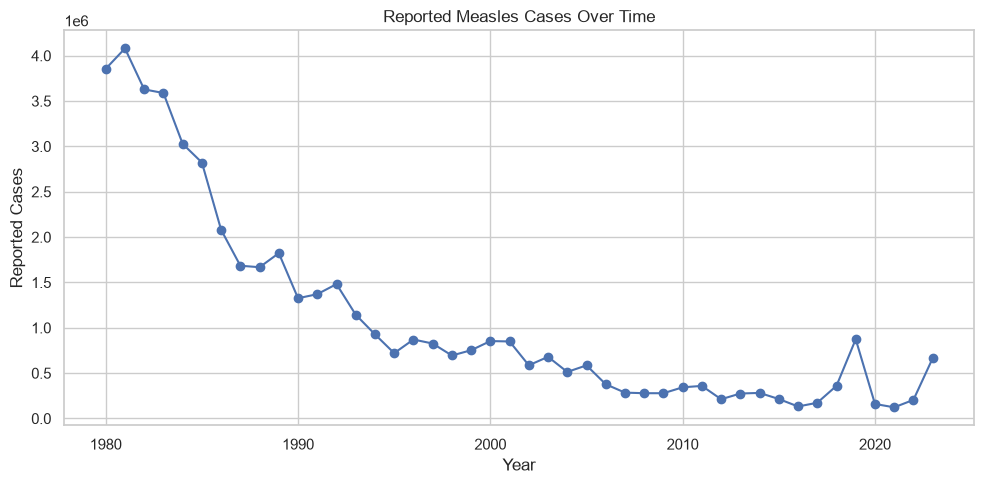

In [21]:
# Chart 9: Reported measles cases over time
meas_cases = cases[cases["DISEASE"]=="MEASLES"].copy()
case_trend = meas_cases.groupby("YEAR")["CASES"].sum()
case_trend.plot(marker="o")
plt.title("Reported Measles Cases Over Time")
plt.xlabel("Year"); plt.ylabel("Reported Cases"); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A line chart is appropriate for reported measles cases because year order is meaningful.


##### 2. What is/are the insight(s) found from the chart?

The trend shows how the total reported measles cases in the country-level dataset change over time.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Monitoring disease-case trends alongside vaccination coverage can help public-health teams identify periods that need additional investigation.


#### Chart - 10

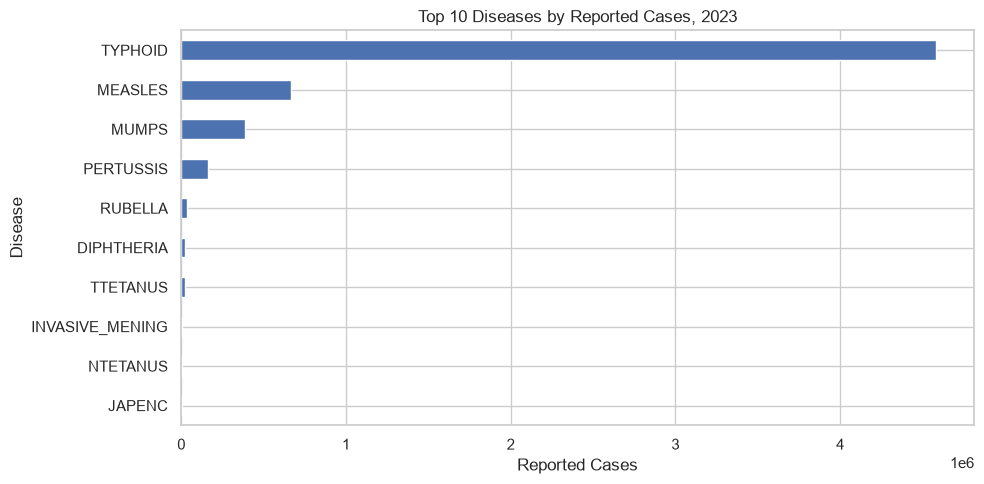

In [22]:
# Chart 10: Total reported cases by disease in 2023
c23 = cases[cases["YEAR"]==2023].groupby("DISEASE")["CASES"].sum().sort_values(ascending=False).head(10)
c23.sort_values().plot(kind="barh")
plt.title("Top 10 Diseases by Reported Cases, 2023")
plt.xlabel("Reported Cases"); plt.ylabel("Disease"); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart is suitable for a top-10 disease comparison because it makes the relative magnitude of case counts easy to read.


##### 2. What is/are the insight(s) found from the chart?

The 2023 data show that reported case counts vary substantially by disease.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Disease-specific case comparisons can help focus analytical attention on diseases with larger reported burdens in the dataset.


#### Chart - 11

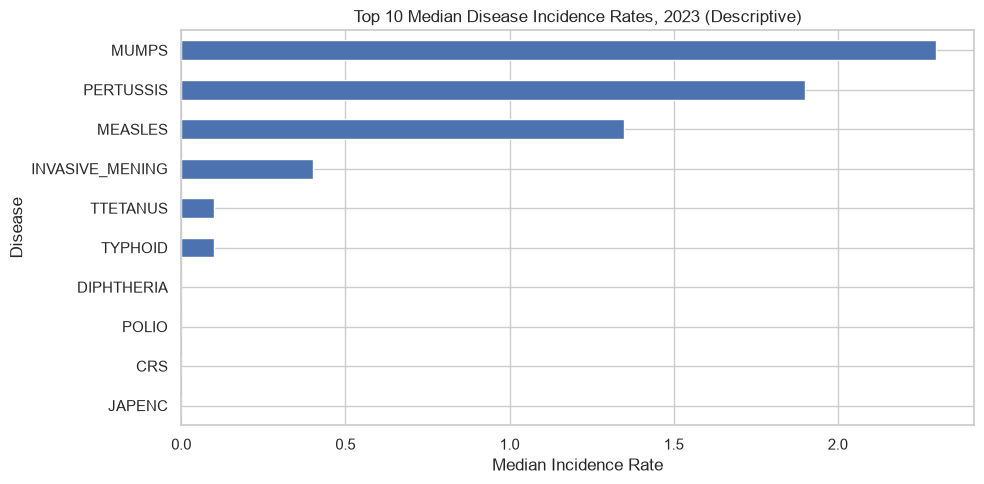

In [23]:
# Chart 11: Median incidence rate by disease in 2023
# Caution: incidence denominators differ by disease, so this is a descriptive view only.
i23 = incidence[incidence["YEAR"]==2023].groupby("DISEASE")["INCIDENCE_RATE"].median().sort_values(ascending=False).head(10)
i23.sort_values().plot(kind="barh")
plt.title("Top 10 Median Disease Incidence Rates, 2023 (Descriptive)")
plt.xlabel("Median Incidence Rate"); plt.ylabel("Disease"); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A bar chart provides a compact comparison of the highest median incidence-rate values in 2023.


##### 2. What is/are the insight(s) found from the chart?

Disease incidence rates differ considerably, but their denominators are not necessarily the same.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This view is useful for exploration only; denominator differences mean the values should not be treated as directly comparable across all diseases.


#### Chart - 12

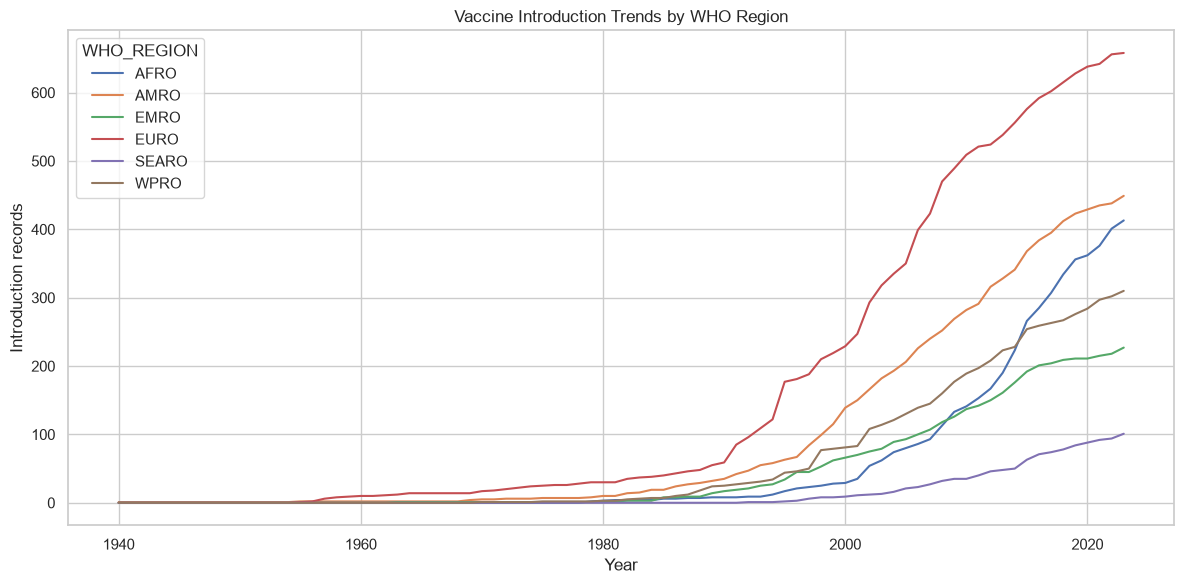

In [24]:
# Chart 12: Vaccine introduction counts by WHO region and year
intro_yes = intro[intro["INTRO"]=="Yes"]
intro_trend = intro_yes.groupby(["YEAR","WHO_REGION"]).size().unstack(fill_value=0)
intro_trend.plot(figsize=(12,6))
plt.title("Vaccine Introduction Trends by WHO Region")
plt.xlabel("Year"); plt.ylabel("Introduction records"); plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A multi-line trend chart shows how vaccine-introduction records vary over time by WHO region.


##### 2. What is/are the insight(s) found from the chart?

Vaccine introduction activity differs across regions and years, indicating variation in introduction timelines in the dataset.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Tracking introduction timelines can support program monitoring and help identify areas for follow-up.


#### Chart - 13

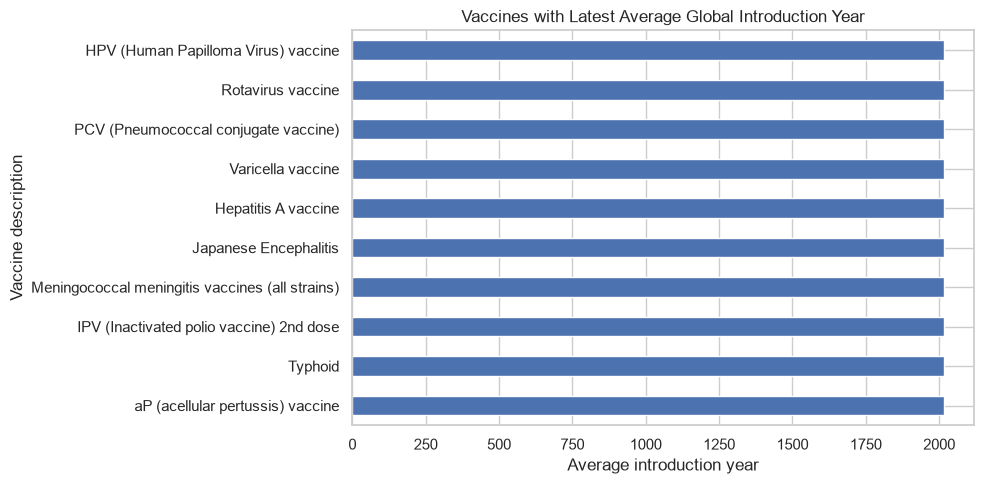

                                                 countries_introduced  \
DESCRIPTION                                                             
HPV (Human Papilloma Virus) vaccine                              1144   
Rotavirus vaccine                                                1200   
PCV (Pneumococcal conjugate vaccine)                             1828   
Varicella vaccine                                                 514   
Hepatitis A vaccine                                               289   
Japanese Encephalitis                                             130   
Meningococcal meningitis vaccines (all strains)                   644   
IPV (Inactivated polio vaccine) 2nd dose                         1523   
Typhoid                                                            30   
aP (acellular pertussis) vaccine                                 1313   

                                                 avg_intro_year  
DESCRIPTION                                              

In [25]:
# Chart 13: Vaccines with latest average global introduction year
latest = intro_yes.groupby("DESCRIPTION").agg(countries_introduced=("ISO_3_CODE","count"), avg_intro_year=("YEAR","mean")).sort_values("avg_intro_year",ascending=False).head(10)
latest["avg_intro_year"].sort_values().plot(kind="barh")
plt.title("Vaccines with Latest Average Global Introduction Year")
plt.xlabel("Average introduction year"); plt.ylabel("Vaccine description"); plt.tight_layout(); plt.show()
print(latest)


##### 1. Why did you pick the specific chart?

A bar chart ranks vaccines by their average introduction year, focusing on the latest average years in the dataset.


##### 2. What is/are the insight(s) found from the chart?

The selected vaccines have different average introduction years, illustrating variation in the timing of introduction across countries.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can support historical review of vaccine rollout patterns and planning for future data updates.


#### Chart - 14 - Correlation Heatmap

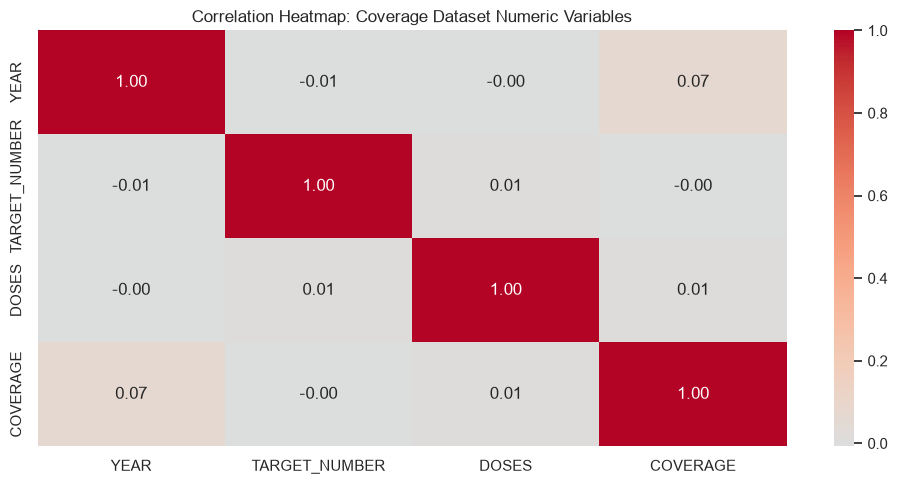

In [26]:
# Chart 14: Correlation heatmap for key numeric vaccination variables
num = coverage[["YEAR","TARGET_NUMBER","DOSES","COVERAGE"]].corr(numeric_only=True)
sns.heatmap(num, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Coverage Dataset Numeric Variables")
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap summarizes relationships among numeric variables in the coverage dataset.


##### 2. What is/are the insight(s) found from the chart?

The heatmap helps identify which numeric variables move together, but correlation does not establish causation.


#### Chart - 15 - Pair Plot

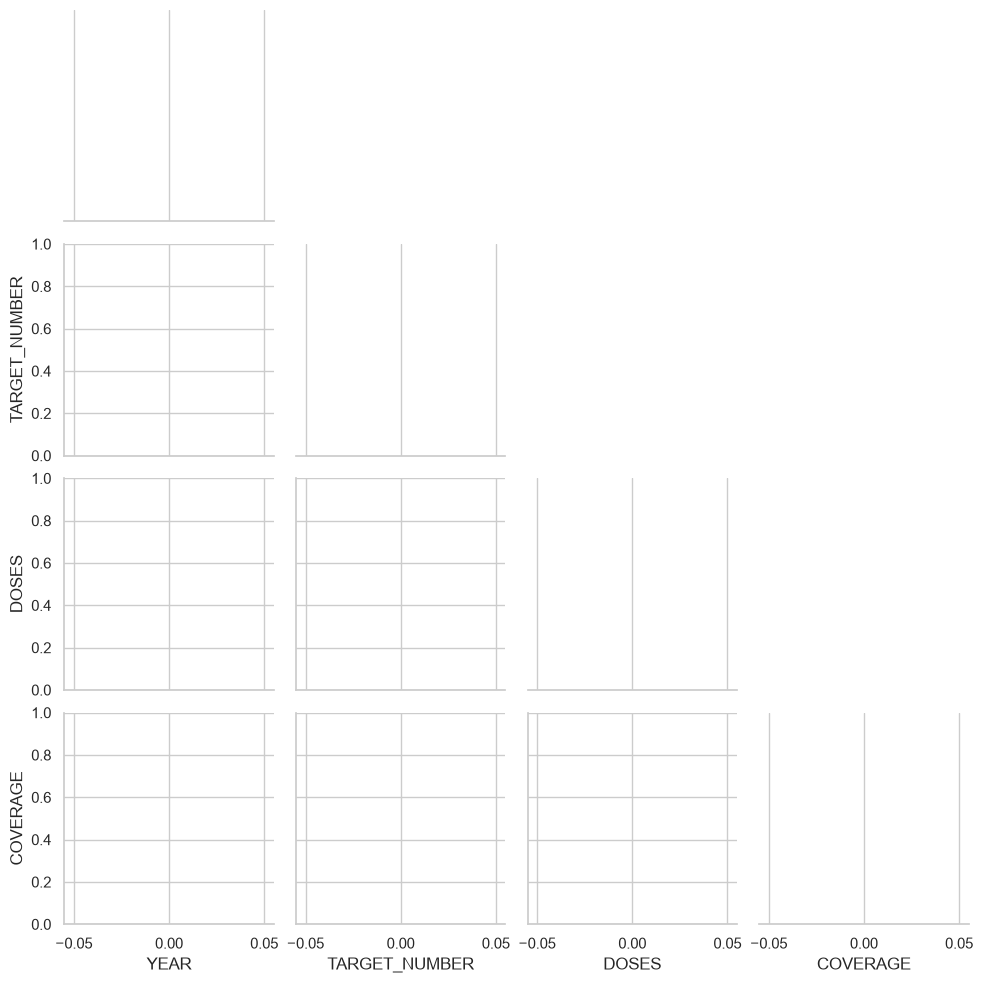

In [27]:
# Chart 15: Pair plot of selected vaccination variables
pair = coverage[(coverage["COVERAGE_CATEGORY"]=="WUENIC") & coverage["COVERAGE"].notna()][["YEAR","TARGET_NUMBER","DOSES","COVERAGE"]].dropna()
pair = pair.sample(min(1500, len(pair)), random_state=42)
sns.pairplot(pair, corner=True, plot_kws={"alpha":0.25,"s":15})
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot provides a compact view of distributions and pairwise relationships among key numeric vaccination variables.


##### 2. What is/are the insight(s) found from the chart?

The pair plot helps inspect possible relationships between year, target size, doses, and coverage before more formal modeling or statistical testing.


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Use the dashboards and cleaned database as a monitoring layer: track vaccination coverage over time, compare WHO-region and country-level gaps, review disease-case and incidence patterns, and monitor vaccine introduction and schedule information. Prioritize deeper investigation of persistent low-coverage areas and unusual disease indicators. Because incidence denominators differ and the analysis is observational, program decisions should combine these findings with epidemiological context and other population-level information.


# **Conclusion**

The project creates an end-to-end workflow for vaccination data analysis: data cleaning in Python, structured storage and validation in SQLite/SQL, exploratory analysis, and interactive Power BI dashboards. The EDA shows substantial long-term improvement in global WUENIC coverage, a pandemic-period decline followed by partial recovery, regional differences in coverage, and a descriptive inverse relationship between MCV1 coverage and measles incidence. The analysis also highlights important limitations, including varying incidence denominators and the absence of demographic variables such as gender, education, and urban/rural status. The resulting database, notebooks, cleaned CSV outputs, and Power BI report provide a reusable analytical foundation for monitoring vaccination coverage, disease indicators, regional differences, and vaccine introduction patterns.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***